In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df_trades = pd.read_csv("historical_data.csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
print("Trades shape:", df_trades.shape)
print("Sentiment shape:", df_sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [4]:
print(df_trades.columns)
print(df_sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
df_trades.isna().sum()
df_sentiment.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
df_trades.columns = df_trades.columns.str.strip().str.replace(" ", "_")
df_sentiment.columns = df_sentiment.columns.str.strip().str.replace(" ", "_")

In [7]:
df_trades['Timestamp'] = df_trades['Timestamp'].astype('int64')
df_trades['Timestamp'] = pd.to_datetime(df_trades['Timestamp'], unit='ms')
df_trades['date'] = df_trades['Timestamp'].dt.normalize()

In [8]:
print(df_trades['date'].min(), df_trades['date'].max())

2023-03-28 00:00:00 2025-06-15 00:00:00


In [9]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

In [10]:
print(df_sentiment['date'].min(), df_sentiment['date'].max())

2018-02-01 00:00:00 2025-05-02 00:00:00


In [11]:
df_merged = df_trades.merge(
    df_sentiment[['date','classification']],
    on='date',
    how='left'
)

In [12]:
df_merged['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [13]:
daily_pnl = df_merged.groupby(['Account','date'])['Closed_PnL'].sum().reset_index()

In [14]:
df_merged['win'] = df_merged['Closed_PnL'] > 0

In [15]:
win_rate_sentiment = df_merged.groupby('classification')['win'].mean()
print(win_rate_sentiment)

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


In [16]:
pnl_by_sentiment = df_merged.groupby('classification')['Closed_PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed_PnL, dtype: float64


In [17]:
trades_by_sentiment = df_merged['classification'].value_counts()
print(trades_by_sentiment)

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [18]:
long_short = df_merged.groupby(['classification','Side']).size().unstack(fill_value=0)
print(long_short)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


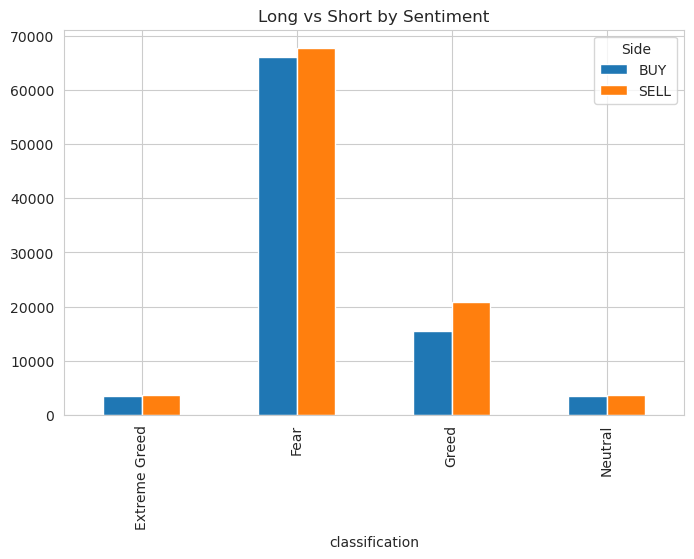

In [19]:
long_short.plot(kind='bar', figsize=(8,5))
plt.title("Long vs Short by Sentiment")
plt.show()

In [20]:
trades_per_trader = df_merged.groupby('Account').size()
median_trades = trades_per_trader.median()

df_merged['freq_segment'] = df_merged['Account'].map(
    lambda x: 'High Frequency' if trades_per_trader[x] > median_trades else 'Low Frequency'
)

In [21]:
win_rate_trader = df_merged.groupby('Account')['win'].mean()
median_win = win_rate_trader.median()

df_merged['performance_segment'] = df_merged['Account'].map(
    lambda x: 'Consistent Winner' if win_rate_trader[x] > median_win else 'Inconsistent'
)

In [22]:
segment_analysis = df_merged.groupby(
    ['freq_segment','classification']
)['Closed_PnL'].mean().unstack()

print(segment_analysis)

classification  Extreme Greed       Fear       Greed     Neutral
freq_segment                                                    
High Frequency      26.658319  46.013950   70.575898    4.055615
Low Frequency      -48.382749  75.639873  234.886424  356.722004


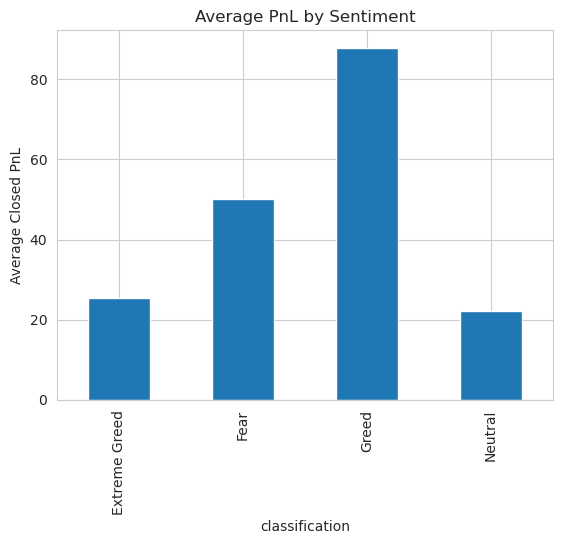

In [23]:
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

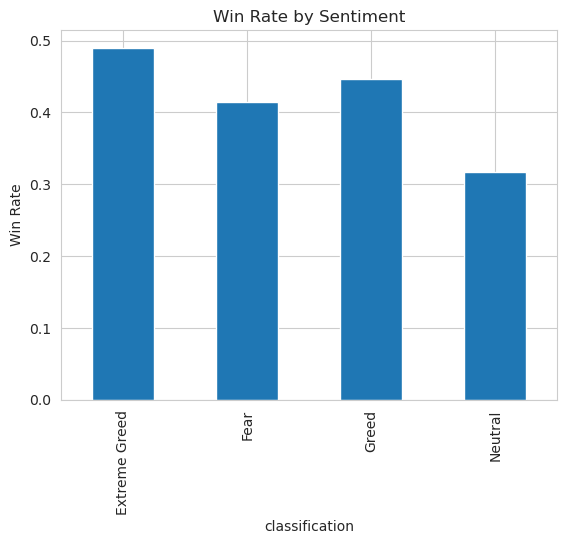

In [24]:
win_rate_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

In [ ]:
Key Insights:
1.Market activity increases during emotional extremes (especially Fear)
2.Trades during Greed phase are most profitable.
Neutral markets give weak returns.
3.Extreme Greed gives better consistency (higher win probability).
Neutral sentiment performs worst.

In [ ]:
Strategy:
Strategy1: Trend-following strategy works best here.
Strategy2: Quick profit booking (scalp / short-term trades)
Strategy3: Use smaller position size + strict stop loss

In [ ]:
1-Page Summary Template:

Objective:

To analyze how market sentiment influences trader performance and behavioral patterns.

Methodology:

Cleaned and aligned daily sentiment & trader datasets

Created daily performance metrics

Compared Fear vs Greed periods

Segmented traders based on leverage and frequency

Key Findings:

Traders increase leverage during Greed periods

PnL volatility rises significantly during Greed

High-leverage traders underperform in Fear markets

Recommendations:

Dynamic leverage adjustment based on sentiment

Risk control mechanisms during high volatility periods

In [ ]:
How to Run:

Clone the repository

Install dependencies:

pip install -r requirements.txt

Open the notebook:

jupyter notebook

Run all cells